In [16]:
# 이 코드 셀을 실행하여 현재 커널에 직접 라이브러리를 설치합니다.
%pip install pandas matplotlib seaborn

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd 

In [18]:
df = pd.read_csv('korea-power-plant-data.csv',encoding ='cp949')

In [19]:
print(df.head())

   번호    구분 발전소명  호기    노형       원자로공급사  용량1(MWe)  용량2(MWe)       건설허가일  \
0   1  정지원전   고리  #1   PWR          W/H       587       587  1972-05-31   
1   2  정지원전   월성  #1  PHWR  AECL(CANDU)       679       679  1978-02-15   
2   1  운영원전   고리  #2   PWR          W/H       650      4550  1978-11-18   
3   2  운영원전   고리  #3   PWR          W/H       950      4550  1979-12-24   
4   3  운영원전   고리  #4   PWR          W/H       950      4550  1979-12-24   

   착공일(기초굴착일)       운영허가일     상업운전개시일     설계수명만료일  
0  1971-11-15  1972-05-31  1978-04-29  2017-06-18  
1  1977-05-03  1978-02-15  1983-04-22  2019-12-24  
2  1977-03-01  1983-08-10  1983-07-25  2023-04-08  
3  1979-04-09  1984-09-29  1985-09-30  2024-09-28  
4  1979-04-09  1985-08-07  1986-04-29  2025-08-06  


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   번호          32 non-null     int64 
 1   구분          32 non-null     object
 2   발전소명        32 non-null     object
 3   호기          32 non-null     object
 4   노형          32 non-null     object
 5   원자로공급사      32 non-null     object
 6   용량1(MWe)    32 non-null     int64 
 7   용량2(MWe)    32 non-null     int64 
 8   건설허가일       32 non-null     object
 9   착공일(기초굴착일)  32 non-null     object
 10  운영허가일       32 non-null     object
 11  상업운전개시일     32 non-null     object
 12  설계수명만료일     32 non-null     object
dtypes: int64(3), object(10)
memory usage: 3.4+ KB


In [21]:
df.describe()

,번호,용량1(MWe),용량2(MWe)
count,32.000000,32.000000,32.000000
mean,11.375000,1028.625000,5197.375000
std,8.221726,249.831524,2445.413676
min,1.000000,587.000000,587.000000
25%,3.750000,950.000000,3775.000000
50%,10.500000,1000.000000,4550.000000
75%,18.250000,1100.000000,6600.000000
max,26.000000,1400.000000,8700.000000


In [22]:
# date_columns = ['건설허가일','착공일(기초굴착일)','운영허가일','상업운전개시일','설계수명만료일']

# for col in date_columns:
#     df[col] = pd.to_datetime(df[col],errors = 'corece')

# df.info()

# 1. 날짜 형식으로 바꿀 컬럼들의 이름을 리스트로 만듭니다.
date_columns = ['건설허가일', '착공일(기초굴착일)', '운영허가일', '상업운전개시일', '설계수명만료일']

# 2. for 반복문을 사용해서 리스트에 있는 모든 컬럼을 한 번에 datetime 형식으로 변환합니다.
#    errors='coerce' 옵션을 추가하여, 변환할 수 없는 값은 NaT(결측치)로 만듭니다.
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 3. 변환이 잘 되었는지 다시 확인합니다.
#    non-null count가 줄어든 컬럼이 있다면, 그 컬럼에 변환 불가능한 값이 있었다는 뜻입니다.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   번호          32 non-null     int64         
 1   구분          32 non-null     object        
 2   발전소명        32 non-null     object        
 3   호기          32 non-null     object        
 4   노형          32 non-null     object        
 5   원자로공급사      32 non-null     object        
 6   용량1(MWe)    32 non-null     int64         
 7   용량2(MWe)    32 non-null     int64         
 8   건설허가일       32 non-null     datetime64[ns]
 9   착공일(기초굴착일)  32 non-null     datetime64[ns]
 10  운영허가일       28 non-null     datetime64[ns]
 11  상업운전개시일     28 non-null     datetime64[ns]
 12  설계수명만료일     28 non-null     datetime64[ns]
dtypes: datetime64[ns](5), int64(3), object(5)
memory usage: 3.4+ KB


In [23]:
# '발전소명'으로 그룹을 묶고, 각 그룹의 '용량1(MWe)' 컬럼의 평균 계산
plant_avg = df.groupby('발전소명')['용량1(MWe)'].mean()
print(plant_avg)

발전소명
고리      784.250000
새울     1400.000000
신고리    1000.000000
신월성    1000.000000
신한울    1400.000000
월성      694.750000
한빛      983.333333
한울      983.333333
Name: 용량1(MWe), dtype: float64


In [36]:
#상업운전 개시 연도별 원전 수 분석
df['개시연도'] = df['상업운전개시일'].dt.year
yearly_plant_count = df['개시연도'].value_counts().sort_index()
print(yearly_plant_count)

개시연도
1978.0    1
1983.0    2
1985.0    1
1986.0    2
1987.0    1
1988.0    1
1989.0    1
1995.0    1
1996.0    1
1997.0    1
1998.0    2
1999.0    2
2002.0    2
2004.0    1
2005.0    1
2011.0    1
2012.0    2
2015.0    1
2016.0    1
2019.0    1
2022.0    1
2024.0    1
Name: count, dtype: int64


In [34]:
df['수명기간'] = df['설계수명만료일'] - df['상업운전개시일']
print(df[['발전소명','수명기간']].sort_values(by='수명기간').reset_index(drop=True))

   발전소명       수명기간
0    월성 10715 days
1    월성 10722 days
2    월성 10773 days
3    월성 13395 days
4    한울 14181 days
5    고리 14243 days
6    고리 14295 days
7   신고리 14324 days
8    한울 14326 days
9    한울 14333 days
10   한울 14334 days
11   한빛 14338 days
12   고리 14344 days
13   한울 14347 days
14  신월성 14357 days
15   한빛 14364 days
16  신월성 14367 days
17  신고리 14378 days
18   한빛 14396 days
19   한빛 14400 days
20   한빛 14406 days
21   한울 14448 days
22   한빛 14463 days
23   고리 14502 days
24  신한울 21398 days
25   새울 21497 days
26  신한울 21703 days
27   새울 21705 days
28   새울        NaT
29   새울        NaT
30  신한울        NaT
31  신한울        NaT


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   번호          32 non-null     int64          
 1   구분          32 non-null     object         
 2   발전소명        32 non-null     object         
 3   호기          32 non-null     object         
 4   노형          32 non-null     object         
 5   원자로공급사      32 non-null     object         
 6   용량1(MWe)    32 non-null     int64          
 7   용량2(MWe)    32 non-null     int64          
 8   건설허가일       32 non-null     datetime64[ns] 
 9   착공일(기초굴착일)  32 non-null     datetime64[ns] 
 10  운영허가일       28 non-null     datetime64[ns] 
 11  상업운전개시일     28 non-null     datetime64[ns] 
 12  설계수명만료일     28 non-null     datetime64[ns] 
 13  개시연도        28 non-null     float64        
 14  수명기간        28 non-null     timedelta64[ns]
dtypes: datetime64[ns](5), float64(1), int64(3), object(5), time

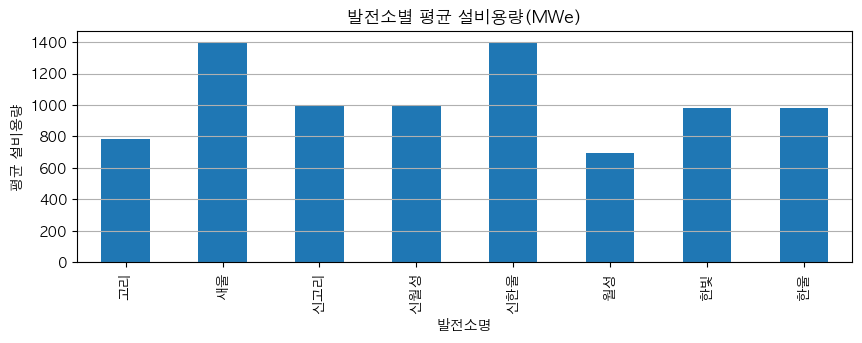

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

#한글 폰트 설정 해줘야 그래프에서 한글 안 깨짐
plt.rc('font',family='AppleGothic')

#발전소별 평균 설비용량 막대 그래프 그리기
plt.figure(figsize=(10,3))
plant_avg.plot(kind='bar')
plt.title('발전소별 평균 설비용량(MWe)')
plt.xlabel('발전소명')
plt.ylabel('평균 설비용량')
# plt.xticks(rotation=45) #x축 라벨 45도 회전
plt.grid(axis='y') #y축으로 줄눈 그리기!
plt.show()


In [ ]:
# 